<h1>MNE, Elephant, Numpy, Matplotlib & spol.</h1>

General usage of those classes in way to understand and analyse EEG signal. To get basic knowladge before I jump to cold-hard ❀IN A CORE TO BE BOOR EEG❀

First we need to add import classes and basic notebook styling to not get lost in the data.

<b><span style="color:pink"> WARNINGS: </span></b>
> DO not use montage.plot unless it is for 3d


In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import elephant

import warnings as w

devider = "⚬──────────✧──────────⚬───── ⋆⋅☆⋅⋆ ─────⚬──────────✧──────────⚬"
dev = "‿̩͙⊱༒︎༻♱༺༒︎⊰‿̩͙"
line = "\n❀----------------------------------------------------------❀\n"
yaas = "\n(˶ᐢ ᵕ ᐢ˶)\n"
nomcat = "\n♡╱|_\n(`O-`7\n |、⁻〵\n じしˍ,)ノ"

⚬──────────✧──────────⚬‿̩͙⊱༒︎༻♱༺༒︎⊰‿̩͙⚬──────────✧──────────⚬
<h2>MNE and file finding, opening and info class</h2>

basic bitch stuff 

In [2]:
#path to file
path = "./../bigData/C01/ica/C01_2024-11-16_10-44-51_RS_before_ica.fif" #second file opens itself

#input output reading function
with w.catch_warnings():
    w.simplefilter("ignore", RuntimeWarning)
    ica = mne.io.read_raw_fif(fname=path, preload=False, verbose=True) #preload=False dokud nechceš aby ti bouchnul laptop

print(line)
print(ica, line)
print(ica.info)


Opening raw data file ./../bigData/C01/ica/C01_2024-11-16_10-44-51_RS_before_ica.fif...
    Range : 0 ... 4287999 =      0.000 ...   536.000 secs
Ready.
Opening raw data file /home/manka/EEG/BoredEEG/Notebook/../bigData/C01/ica/C01_2024-11-16_10-44-51_RS_before_ica-1.fif...
    Range : 4288000 ... 4807672 =    536.000 ...   600.959 secs
Ready.

❀----------------------------------------------------------❀

<Raw | C01_2024-11-16_10-44-51_RS_before_ica.fif, 125 x 4807673 (601.0 s), ~150 KiB, data not loaded> 
❀----------------------------------------------------------❀

<Info | 13 non-empty values
 bads: []
 ch_names: Fp1, Fpz, Fp2, F7, F3, Fz, F4, F8, FC5, FC1, FC2, FC6, M1, T7, ...
 chs: 124 EEG, 1 EMG
 custom_ref_applied: True
 device_info: 2 items (dict)
 dig: 127 items (3 Cardinal, 124 EEG)
 file_id: 4 items (dict)
 highpass: 1.0 Hz
 lowpass: 1000.0 Hz
 meas_date: 2024-11-16 10:44:51 UTC
 meas_id: 4 items (dict)
 nchan: 125
 projs: []
 sfreq: 8000.0 Hz
 subject_info: <subject_info | 

⚬──────────✧──────────⚬‿̩͙⊱༒︎༻♱༺༒︎⊰‿̩͙⚬──────────✧──────────⚬
<h2>Montage,- setting, what is it, how it looks</h2>

Description of cap(sensor location and naming) which was used durring EEG

Standard1005, 1010 & 1020 is most used caps and it coresponds to distance between each electrodes based on percentage of head area plus two on ears 

Ploting 2d montage via
<span style="color:red">
    montage.plot
</span>
is fucking sick, do not use it. It works just fine for 3d. Reason is that nobody needs 2d as much. If you really need to plot it use mne class <span style="color:red"> plot_sensors </span>

In [35]:
i_montage= mne.channels.make_standard_montage("standard_1005")
ica.set_montage(i_montage)

<Raw | C01_2024-11-16_10-44-51_RS_before_ica.fif, 125 x 4807673 (601.0 s), ~152 KiB, data not loaded>

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 343 channels>

❀----------------------------------------------------------❀

4 duplicate electrode labels found:
T7/T3, T8/T4, P7/T5, P8/T6
Plotting 339 unique labels.


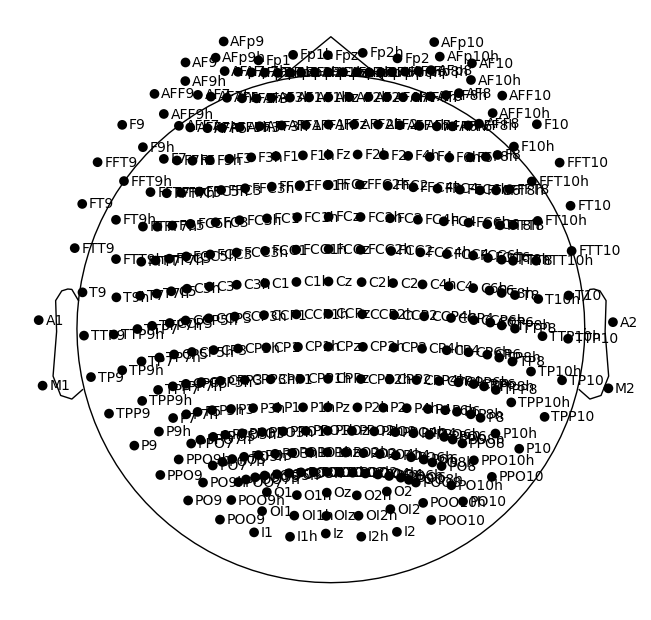

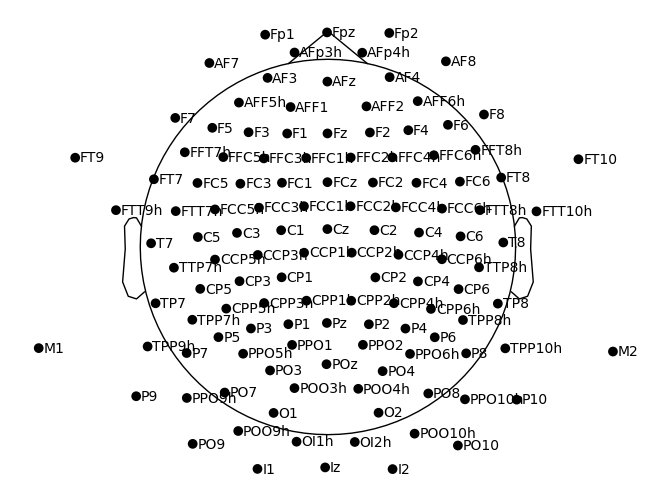

4 duplicate electrode labels found:
T7/T3, T8/T4, P7/T5, P8/T6
Plotting 339 unique labels.


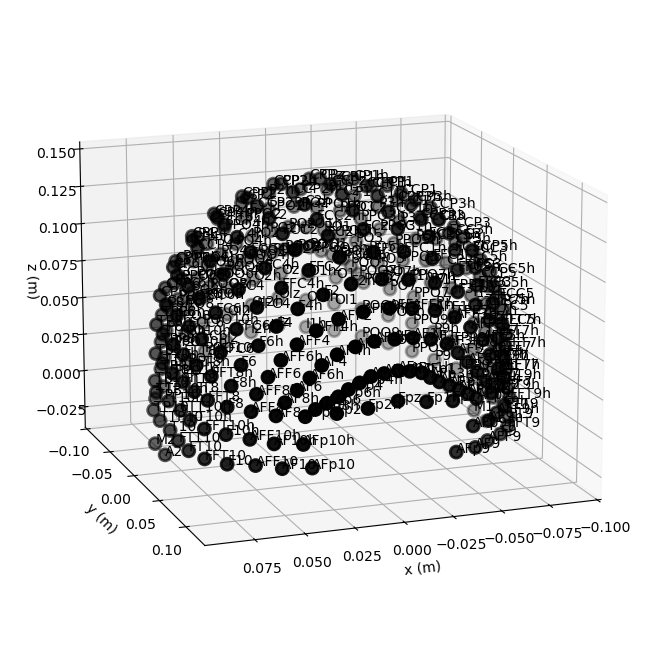

In [36]:
def spam():
    print(i_montage)
    
    print(line)
    
    #kill me method of printing montage
    i_montage.plot(
        kind="topomap"
    )
    
    #better ig, a bit saner
    ica.plot_sensors(
        show_names=True,
        kind="topomap",
        sphere='auto')
    
    i_montage.plot(kind="3d", show=False).gca().view_init(azim=70, elev=15)
    

spam()

⚬──────────✧──────────⚬‿̩͙⊱༒︎༻♱༺༒︎⊰‿̩͙⚬──────────✧──────────⚬
<h2><b><span style="color:pink">Class mne.info()</span></b></h2>

Looking at the info it tells us:

Names of channels, 124 electrodes all around head and one final cap <span style='color:red'>(?), </span> date & id of measurement

<b><span style="color:pink">recording_len = ica.n_times </span></b>
how manny points of information in eeg we got. So we can compute the exact length of recording in minutes or seconds...

‿̩͙⊱༒︎༻♱༺༒︎⊰‿̩͙

What we don't know: 

Whats EMG, costom ref applied, sex 0, projs, dig information (wha we can digout ?)


In [3]:
information = ica.info
print(information)
print(line)

freq = information['sfreq']#Frequence of recording == in one second how manny notes it takes
names = information['ch_names']
elect = information['nchan'] #why 125?

recording_len = ica.n_times #recorded points
recording_len = (recording_len/8000)

print(recording_len)
print(information.ch_names)

<Info | 13 non-empty values
 bads: []
 ch_names: Fp1, Fpz, Fp2, F7, F3, Fz, F4, F8, FC5, FC1, FC2, FC6, M1, T7, ...
 chs: 124 EEG, 1 EMG
 custom_ref_applied: True
 device_info: 2 items (dict)
 dig: 127 items (3 Cardinal, 124 EEG)
 file_id: 4 items (dict)
 highpass: 1.0 Hz
 lowpass: 1000.0 Hz
 meas_date: 2024-11-16 10:44:51 UTC
 meas_id: 4 items (dict)
 nchan: 125
 projs: []
 sfreq: 8000.0 Hz
 subject_info: <subject_info | first_name: 1 Control, birthday: 1983-01-01, sex: 0>
>

❀----------------------------------------------------------❀

600.959125
['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'O2', 'AF7', 'AF3', 'AF4', 'AF8', 'F5', 'F1', 'F2', 'F6', 'FC3', 'FCz', 'FC4', 'C5', 'C1', 'C2', 'C6', 'CP3', 'CP4', 'P5', 'P1', 'P2', 'P6', 'PO3', 'PO4', 'FT7', 'FT8', 'TP7', 'TP8', 'PO7', 'PO8', 'FT9', 'FT10', 'TPP9h', 'TPP10h', 'PO9', 'PO10', 'P9', 

⚬──────────✧──────────⚬‿̩͙⊱༒︎༻♱༺༒︎⊰‿̩͙⚬──────────✧──────────⚬
<h2>Data in EEG <b><span style="color:pink">mne.data() </h2>

Touple inside an touple >> <span style="color:red"> << nah it's numpy.array inside an touple!

<b>Tuples</b>

Tuples is ordered, copy posible struture. Storing big data measurement. Two touples are additional. Touple can be changed by this moves.
> Addition, subset [2:4], reversed [:-1], removing first item [1:] atp...

> Deletion

> Asterisk *

<b>Numpy arrays</b>





In [38]:
dataI = ica.get_data(picks=['CP1'])
print(dataI)
print(dataI[0])
print(dataI[0][2:4])#2 a 3 print
#print(dataI[0].shape())

#print(dataI.shape()) #is tuple numpy.ndarray)

a = dataI[0][0]
print(type(a))


[[-5.24971143e-11  1.62590879e-06  2.72609691e-06 ...  2.81165990e-06
   1.51163204e-06 -5.24971143e-11]]
[-5.24971143e-11  1.62590879e-06  2.72609691e-06 ...  2.81165990e-06
  1.51163204e-06 -5.24971143e-11]
[2.72609691e-06 3.01467117e-06]
<class 'numpy.float64'>


⚬──────────✧──────────⚬‿̩͙⊱༒︎༻♱༺༒︎⊰‿̩͙⚬──────────✧──────────⚬
<h2>Plotting</h2>

Let's not only plot demise of the human kind. Plotting EEG in tyme domain got two choises at the beginning. 

- Build in methods and st/<span style="color:red">You don't... Just don't </span> <b>xXx</b> <span style="color:olive">Using ploting methods :

    - <span style="color:olive">elephant.signal_processing()
    - <span style="color:olive">get_data()

<h3> Short Time over Amplitude </h3>

First we will look into ploting time over amplitude of short time window using get_data.

As we can see its almost unreadable. So we will get to next station of using procesing that same signal data


[[-3.41411942e-06 -3.16853425e-06 -2.29173338e-06 ...  2.60190268e-06
   2.29496277e-06  1.62362608e-06]]


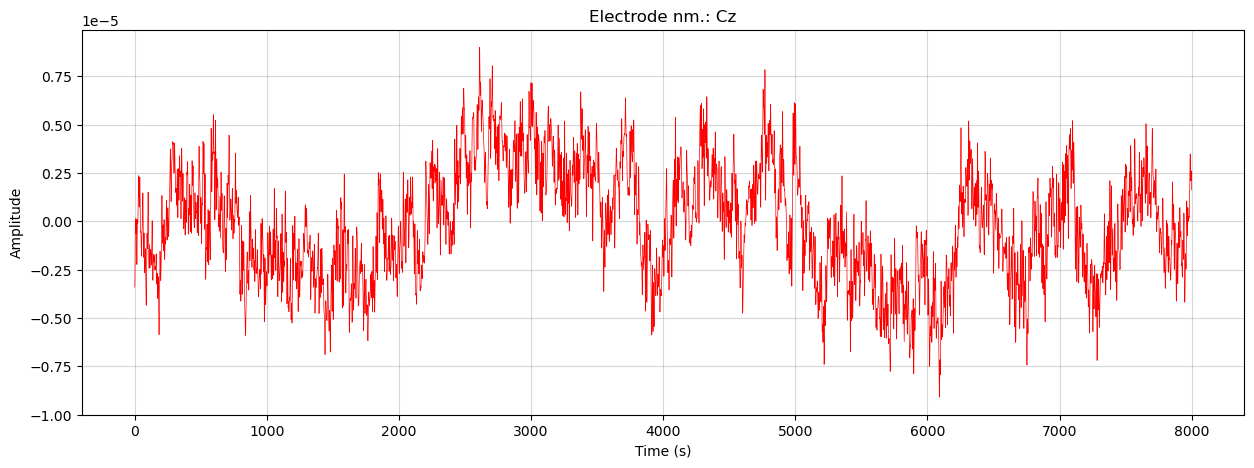

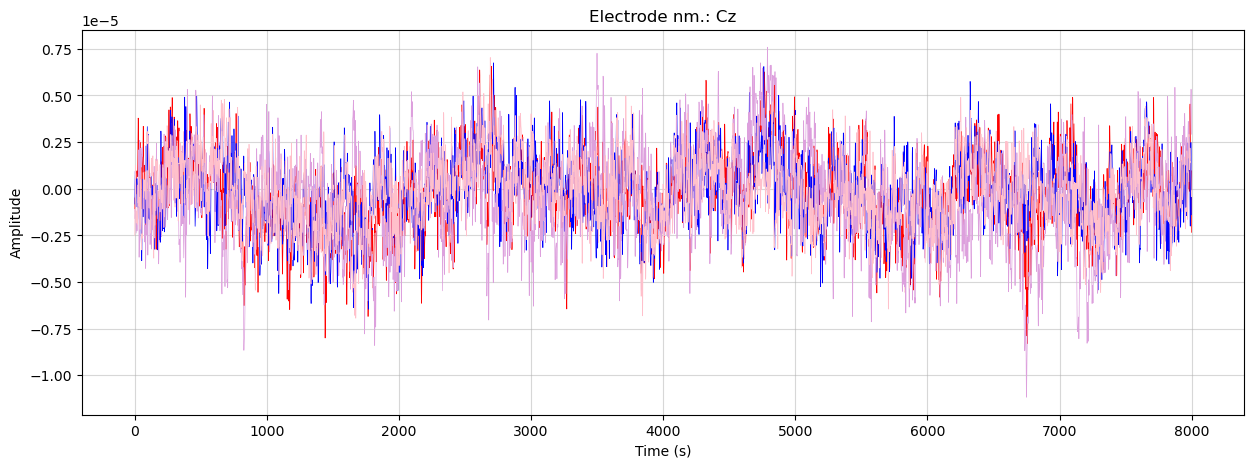

In [4]:
sampling_rate = ica.info['sfreq'] #frekvencia za jednu sekundu

t_min = 22 #odkud 
t_max = 23 #dokud

electrod = 'Cz'
electrodes = ['CP1', 'CP2', 'CP3', 'CP4']

sample = ica.get_data(picks=electrod, start=int(t_min*sampling_rate), stop=int(t_max*sampling_rate))
sample_dif = ica.get_data(picks=electrodes, tmin= t_min, tmax= t_max)

print(sample)
plt.figure(figsize=(15,5))
plt.plot(sample[0], color="red", lw=0.5)
plt.grid(alpha=0.5)
plt.title(f'Electrode nm.: {electrod}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

#print(sample_dif)
plt.figure(figsize=(15,5))
plt.plot(sample_dif[0], color="red", lw=0.5)
plt.plot(sample_dif[1], color="blue", lw=0.5)
plt.plot(sample_dif[2], color="plum", lw=0.5)
plt.plot(sample_dif[3], color="pink", lw=0.5)
plt.grid(alpha=0.5)
plt.title(f'Electrode nm.: {electrod}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()


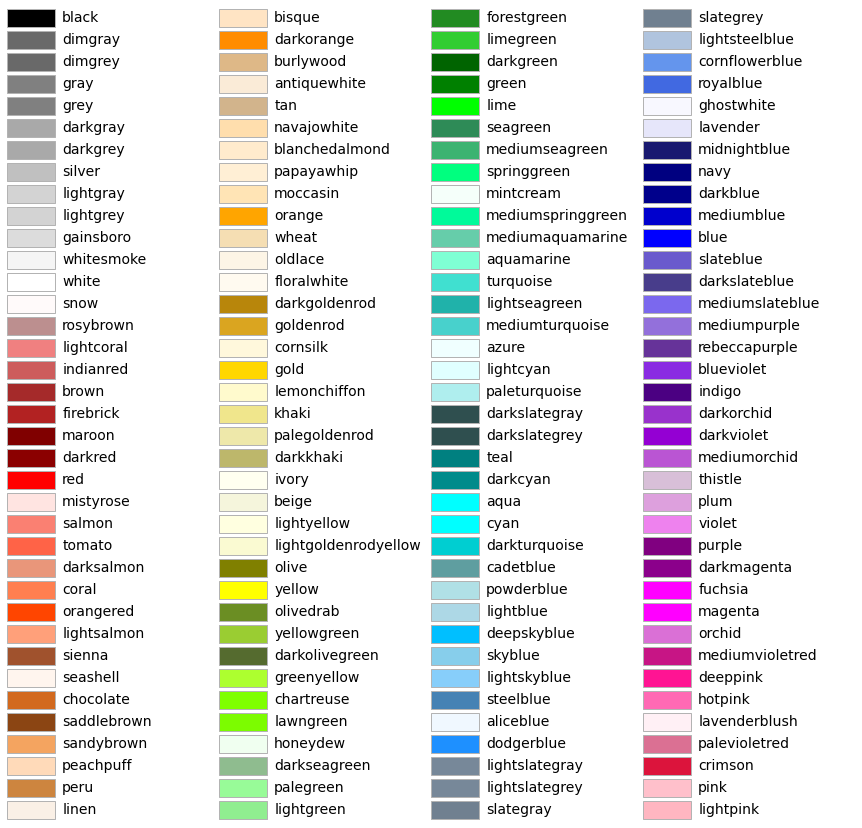

In [116]:
#%run ./MatplotlibColors.py

<h3>Signal processing using elephant</h3>

Elephant is python package for electrophysiology analysis as: spies, LFP(local field potential), analog signaling. 
Input output data in Numpy array mostly.

First plot is just the same. But then we start separating frequencies from each other 

|Wave type|Frequency\[Hz]|Echo|Prominent|
|---------|-------------|-----------------------------------|--------------------|
|Delta|0.5 - 4|Deep stage 3 of NonREM sleep. Also known as slow-wave sleep|
|Theta|4 - 7|Cognition, behavior including learning, memory and spatial navigation in animal. Some says that mostly asleep?|Hippocampus
|Alpha|8 - 13|Mind is awake but relaxed & Alpha cognitive inkling during state of boredom |Pariental and occipital site|
|Beta|13 - 30|Increases after opening eye|Frontal areas and other|
|Gamma|30+|Most complex, less knowladge due to big data|

So now we separated waves from each other 


Just the same plot, but what if we wanted to separate frequencies?


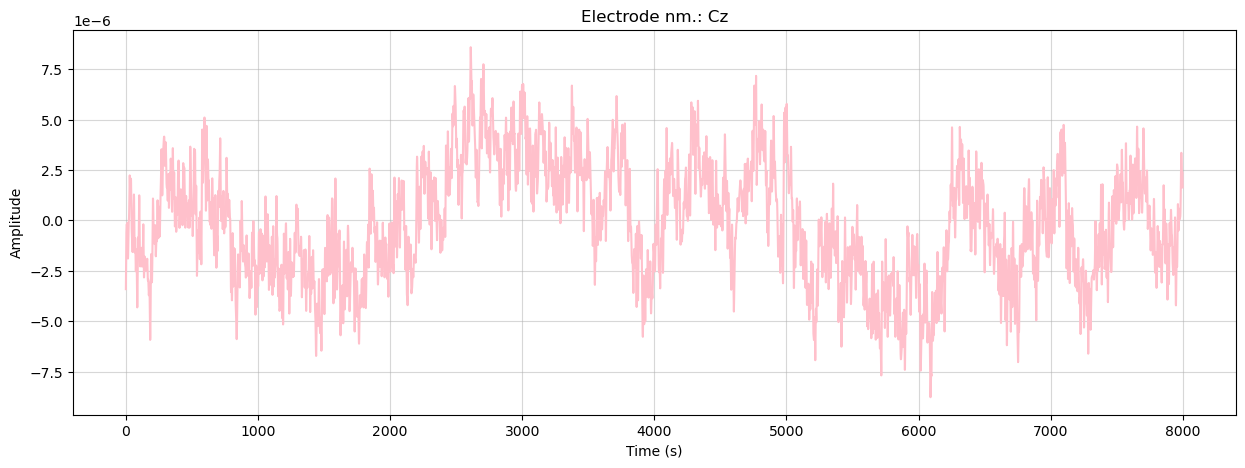

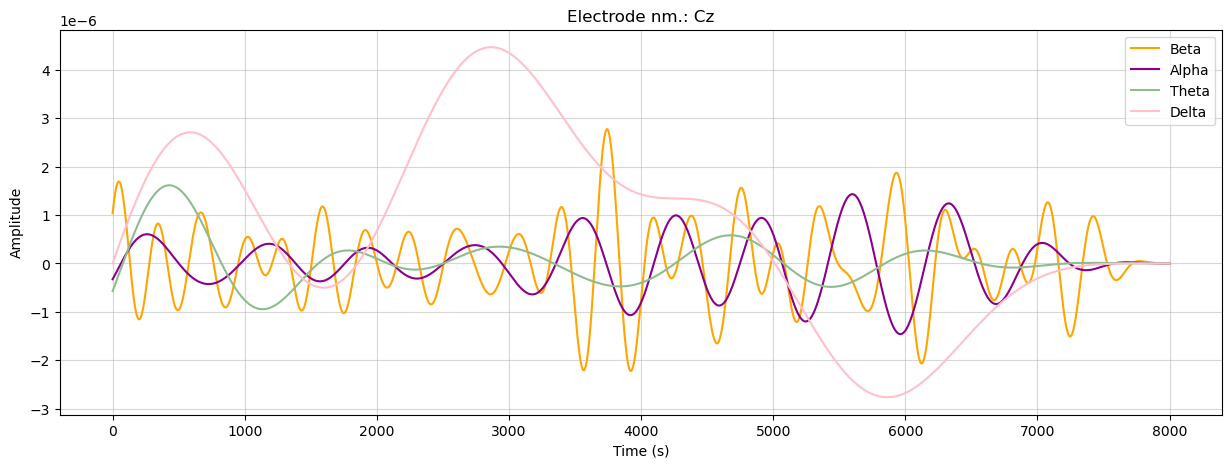

In [5]:
from elephant.signal_processing import butter

sample_processed = butter(sample, highpass_frequency=0, lowpass_frequency=1000, filter_function='sosfiltfilt', sampling_frequency=sampling_rate)

print("Just the same plot, but what if we wanted to separate frequencies?")
plt.figure(figsize=(15,5))
plt.plot(sample_processed[0], color='pink')
plt.grid(alpha=0.5)
plt.title(f'Electrode nm.: {electrod}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

plt.figure(figsize=(15,5))  
"""
plt.plot(
    butter(
        sample,
        highpass_frequency=30,
        filter_function='sosfiltfilt',
        sampling_frequency=sampling_rate
    )[0],
    color='Gainsboro',
    label="Gamma"
)
"""
plt.plot(
    butter(
        sample,
        highpass_frequency=14,
        lowpass_frequency=30,
        filter_function='sosfiltfilt',
        sampling_frequency=sampling_rate
    )[0],
    color='orange',
    label="Beta"
)
plt.plot(
    butter(
        sample,
        highpass_frequency=8,
        lowpass_frequency=13,
        filter_function='sosfiltfilt',
        sampling_frequency=sampling_rate
    )[0],
    color='darkmagenta',
    label="Alpha"
)
plt.plot(
    butter(
        sample,
        highpass_frequency=4,
        lowpass_frequency=7,
        filter_function='sosfiltfilt',
        sampling_frequency=sampling_rate
    )[0],
    color='darkseagreen',
    label="Theta"
)
plt.plot(
    butter(
        sample,
        highpass_frequency=0.5,
        lowpass_frequency=4,
        filter_function='sosfiltfilt',
        sampling_frequency=sampling_rate
    )[0],
    color='pink',
    label="Delta"
) 
plt.legend()
plt.grid(alpha=0.5)
plt.title(f'Electrode nm.: {electrod}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()


<h2><span style="color:plum"><b>I think we did in time domain what we could</h2>

- What I did?
  - [x] Did it all over again
  - [x] Did buy new PC
  - [x] Made a new git for this project
  - [x] Changed the digusting theme
  - [x] Added inline suggestion and documentation  
- What's next?
  - [x] Look at messages from Natka
  - [ ] Watch the videos she send 1/2
  - [x] Sent her this Notebook
  - [ ] Cluster

Ukol: pochopit Verbose